# FrictionVelocity
计算大气边界层中的摩擦速度

#### 参数说明：

| 字段名称 | 类型                      | 描述                                         | 单位                             | 注意事项                         |
| -------- | ------------------------- | -------------------------------------------- | -------------------------------- | -------------------------------- |
| `u_href` | 二维浮点型数组（float32） | 参考高度 h_ref 处的风速                      | 与输入风速单位一致（通常为 m/s） | 必须与其他输入数组具有相同的尺寸 |
| `h_ref`  | 二维浮点型数组（float32） | 参考高度                                     | 长度单位（通常为米）             | 必须与 z_0 使用相同的单位        |
| `z_0`    | 二维浮点型数组（float32） | 植被粗糙度长度，反映地表粗糙程度             | 长度单位（通常为米）             | 必须与 h_ref 使用相同的单位      |
| `mask`   | 二维布尔型数组（bool）    | 计算掩码，True 表示对应格点需计算摩擦速度 u* | 无                               | 必须与其他输入数组具有相同的尺寸 |

#### 方法说明：

| 方法名称   | 描述                                              | 参数                     | 返回值                                                       |
| ---------- | ------------------------------------------------- | ------------------------ | ------------------------------------------------------------ |
| `__init__` | 初始化摩擦速度计算类                              | u_href, h_ref, z_0, mask | 无                                                           |
| `__call__` | 使类实例可调用，直接返回 process() 方法的计算结果 | 无                       | 二维浮点型数组（float32）—— 摩擦速度场                       |
| `process`  | 核心计算方法：计算摩擦速度场                      | 无                       | 二维浮点型数组（float32）—— 摩擦速度场，未计算的格点值为 RMDI |

### 计算原理：

摩擦速度计算公式：\( u* = K \times \frac{u_{href}}{\ln(\frac{h_{ref}}{z_0})} \)

其中：
- \( u* \) 为摩擦速度
- \( K \) 为冯·卡门常数（Von Karman's constant），通常取 0.4
- \( u_{href} \) 为参考高度处的风速
- \( h_{ref} \) 为参考高度
- \( z_0 \) 为植被粗糙度长度



In [5]:
import sys
import os

import meteva_base as meb
import numpy as np

# 获取当前 notebook 所在目录
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
# 获取 wind_calculations 目录路径
wind_calc_dir = os.path.dirname(notebook_dir)
# 添加到 Python 路径
sys.path.insert(0, wind_calc_dir)

from src.wind_downscaling import RoughnessCorrection, FrictionVelocity

# 读取数据变量
u_href_grd = meb.read_griddata_from_nc(r"D:\Work\nimm_improver\wind_calculations\resource\WIND_SPEED_10KM_CHINA.nc")
h_ref_grd = meb.read_griddata_from_nc(r"D:\Work\nimm_improver\wind_calculations\resource\HGT_M_10KM_CHINA.nc")
z_0_grd = meb.read_griddata_from_nc(r"D:\Work\nimm_improver\wind_calculations\resource\COVER_10KM_CHINA.nc")
mask_grd = meb.read_griddata_from_nc(r"D:\Work\nimm_improver\wind_calculations\resource\MASK_10KM_CHINA.nc")
u_href = u_href_grd.values.squeeze()
h_ref = h_ref_grd.values.squeeze()
z_0 = z_0_grd.values.squeeze()
mask = mask_grd.values.squeeze()
mask = mask.astype(bool)

In [6]:
fv = FrictionVelocity(u_href, h_ref, z_0, mask)
ustar = fv()

In [7]:
grd0 = meb.grid([70, 135, 0.1], [17, 55, 0.1], gtime=u_href_grd.time.values, dtime_list=u_href_grd.dtime.values)

ustar_grd = meb.grid_data(grd0, ustar)
# 异常值处理
ustar_grd.values = np.nan_to_num(ustar_grd.values, nan=0.0, posinf=0.0, neginf=0.0)
ustar_grd.values[ustar_grd.values == -32767] = 0


返回结果中自动添加了南海小地图，请注意返回结果中包含了两个绘图框列表


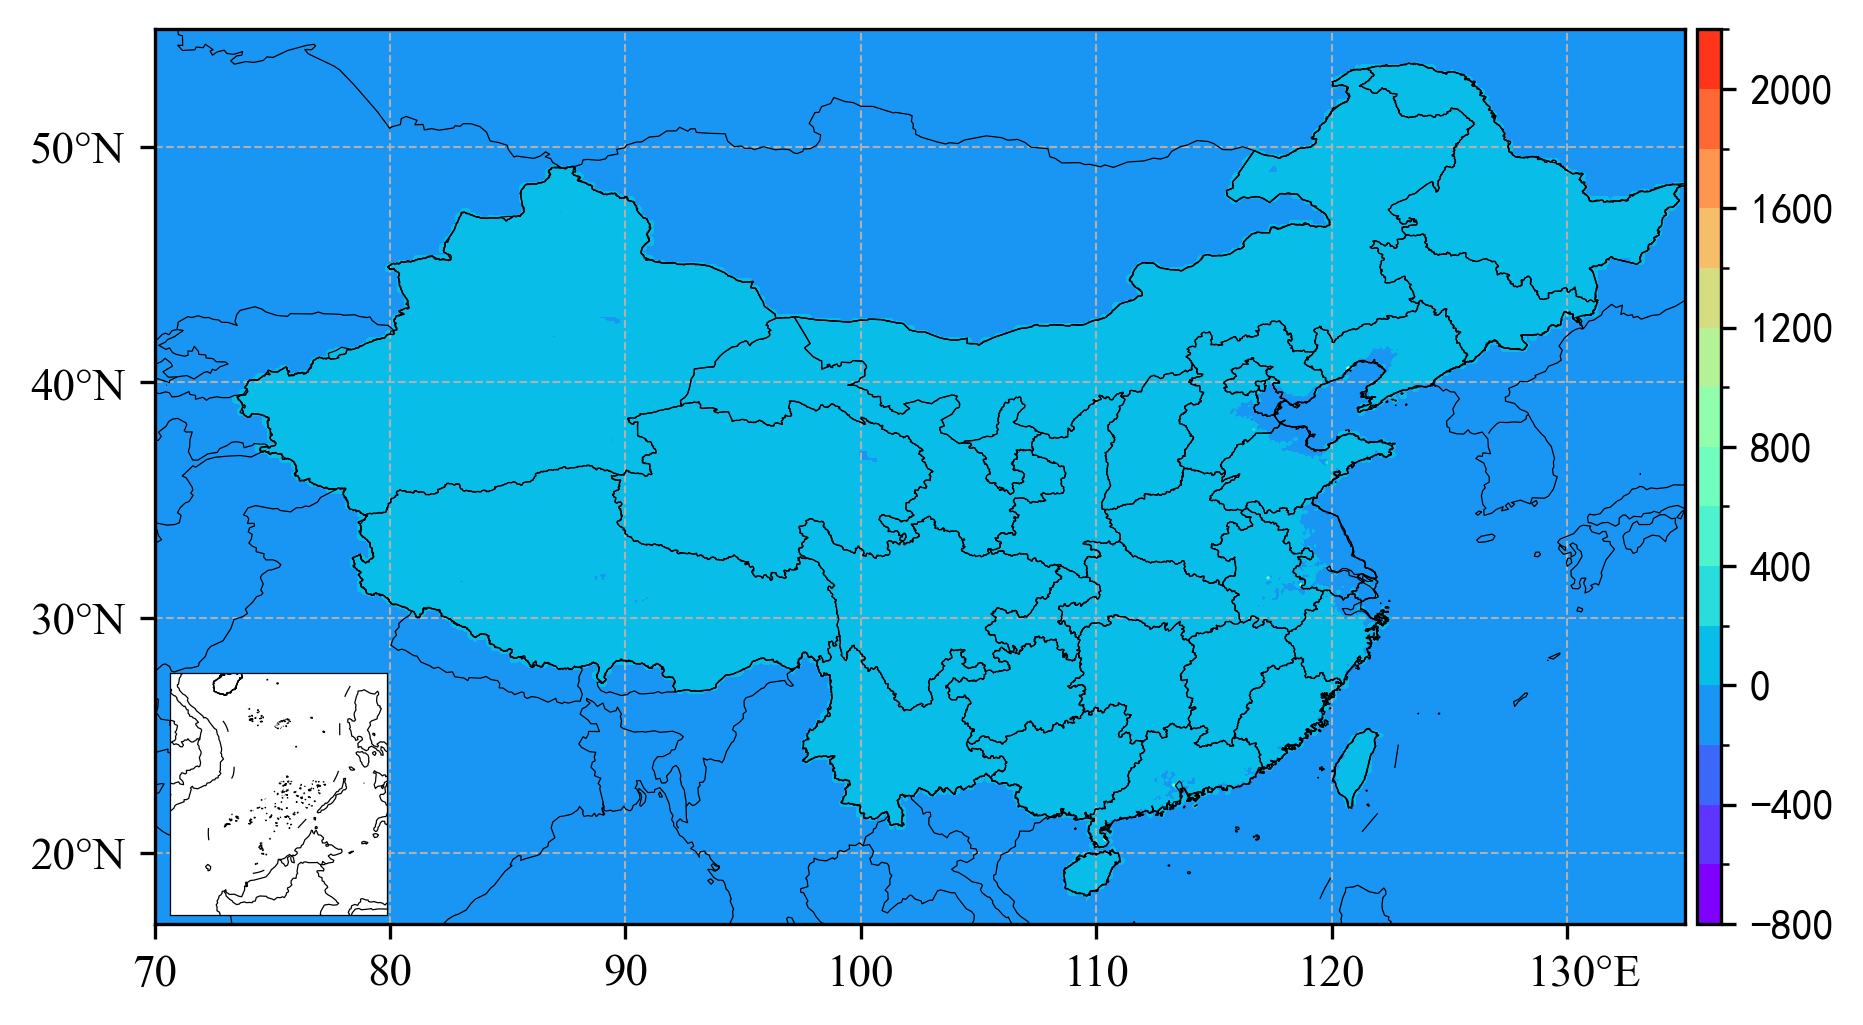

In [8]:
map_extend = [70,135,17,55]
axs,minaxs = meb.creat_axs(1,map_extend,ncol = 1)
# print(axs[0])
image = meb.add_contourf(axs[0], ustar_grd)

# RoughnessCorrectionUtilities

用于计算风速高度订正与粗糙度订正的类

#### 参数说明：

| 字段名称   | 类型                      | 描述                             | 单位                       | 注意事项                                       |
| ---------- | ------------------------- | -------------------------------- | -------------------------- | ---------------------------------------------- |
| `a_over_s` | 二维浮点型数组（float32） | 地形轮廓粗糙度场（无量纲）       | 无                         | 属于辅助数据，计算方法参考 Robinson, D. (2008) |
| `z_0`      | 二维浮点型数组（float32） | 植被粗糙度长度场                 | 长度单位（通常为米）       | 无效值会被设置为海面默认值 Z0M_SEA             |
| `pporo`    | 二维浮点型数组（float32） | 后处理网格地形高度场             | 长度单位（通常为米）       | 用于计算地形高度差                             |
| `modoro`   | 二维浮点型数组（float32） | 插值至后处理网格的模式地形高度场 | 长度单位（通常为米）       | 用于计算地形高度差                             |
| `h_over_2` | 二维浮点型数组（float32） | 半峰谷高度                       | 长度单位（与 sigma 相同）  | 由 sigma2hover2 方法计算得出                   |
| `hcmask`   | 二维布尔型数组（bool）    | 高度订正（HC）掩码               | 无                         | 陆点为 True，海点为 False                      |
| `rcmask`   | 二维布尔型数组（bool）    | 粗糙度订正（RC）掩码             | 无                         | 除海点外，z_0 无效的格点也为 False             |
| `dx_min`   | 浮点型（float）           | 后处理网格无法解析的更小尺度     | 长度单位（与 ppres 相同）  | 计算方法：ppres / 2.0                          |
| `dx_max`   | 浮点型（float）           | 模式网格已解析的更大尺度         | 长度单位（与 modres 相同） | 计算方法：3.0 * modres                         |
| `wavenum`  | 二维浮点型数组（float32） | 地形波数                         | 长度单位的倒数             | 由 _calc_wav 方法计算得出                      |
| `h_ref`    | 二维浮点型数组（float32） | 粗糙度订正的参考高度             | 长度单位（通常为米）       | 由 _calc_h_ref 方法计算得出                    |
| `h_at0`    | 二维浮点型数组（float32） | 后处理网格与模式网格的地形高度差 | 长度单位（通常为米）       | 由 _delta_height 方法计算得出                  |

#### 方法说明：

| 方法名称                    | 描述                                   | 参数                                               | 返回值                    |
| --------------------------- | -------------------------------------- | -------------------------------------------------- | ------------------------- |
| `__init__`                  | 初始化粗糙度订正与高度订正的参数       | a_over_s, sigma, z_0, pporo, modoro, ppres, modres | 无                        |
| `sigma2hover2`              | 计算半峰谷高度                         | sigma                                              | 二维浮点型数组（float32） |
| `_setmask`                  | 生成近似的陆海掩码                     | 无                                                 | Tuple[ndarray, ndarray]   |
| `_calc_wav`                 | 计算典型地形长度尺度对应的波数 k       | 无                                                 | 二维浮点型数组（float32） |
| `_calc_h_ref`               | 计算粗糙度订正的参考高度               | 无                                                 | 二维浮点型数组（float32） |
| `_refinemask`               | 基于缺测值 RMDI 和无效地形高度重新掩码 | 无                                                 | None                      |
| `_delta_height`             | 计算后处理网格与模式网格高度差值       | 无                                                 | 二维浮点型数组（float32） |
| `calc_roughness_correction` | 执行粗糙度订正                         | hgrid, uold, mask                                  | 三维浮点型数组（float32） |
| `_calc_u_at_h`              | 将风速插值到目标高度                   | u_in, h_in, hhere, mask, dolog                     | 二维浮点型数组（float32） |
| `_interpolate_1d`           | 简易一维线性插值函数                   | xup, xlow, at_x, yup, ylow                         | 二维浮点型数组（float32） |
| `_interpolate_log`          | 简易一维对数插值函数                   | xup, xlow, at_x, yup, ylow                         | 二维浮点型数组（float32） |
| `_calc_height_corr`         | 计算高度订正附加项                     | u_a, heightg, mask, onemfrac                       | 三维浮点型数组（float32） |
| `do_rc_hc_all`              | 同时执行粗糙度订正和高度订正           | hgrid, uorig                                       | 三维浮点型数组（float32） |

### 核心功能说明：

1. **粗糙度订正**：通过 `calc_roughness_correction` 方法实现，将参考高度以下的风速廓线替换为随高度对数增长的廓线。

2. **高度订正**：通过 `_calc_height_corr` 方法实现，考虑地形高度差对风速的影响，随高度呈指数衰减。

3. **综合订正**：通过 `do_rc_hc_all` 方法实现，同时执行粗糙度订正和高度订正，返回最终的风速场。

4. **辅助计算**：包括半峰谷高度计算、波数计算、参考高度计算等，为订正提供必要的参数。


In [9]:
import sys
import os

import meteva_base as meb
import numpy as np

# 获取当前 notebook 所在目录
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
# 获取 wind_calculations 目录路径
wind_calc_dir = os.path.dirname(notebook_dir)
# 添加到 Python 路径
sys.path.insert(0, wind_calc_dir)

from src.wind_downscaling import RoughnessCorrection, FrictionVelocity, RoughnessCorrectionUtilities

# 读取数据变量
u_href_grd = meb.read_griddata_from_nc(r"D:\Work\nimm_improver\wind_calculations\resource\WIND_SPEED_10KM_CHINA.nc")
h_ref_grd = meb.read_griddata_from_nc(r"D:\Work\nimm_improver\wind_calculations\resource\HGT_M_10KM_CHINA.nc")
z_0_grd = meb.read_griddata_from_nc(r"D:\Work\nimm_improver\wind_calculations\resource\COVER_10KM_CHINA.nc")
mask_grd = meb.read_griddata_from_nc(r"D:\Work\nimm_improver\wind_calculations\resource\MASK_10KM_CHINA.nc")
u_href = u_href_grd.values.squeeze()
h_ref = h_ref_grd.values.squeeze()
z_0 = z_0_grd.values.squeeze()
mask = mask_grd.values.squeeze()
mask = mask.astype(bool)

grd0 = meb.grid([70, 135, 0.1], [17, 55, 0.1], gtime=u_href_grd.time.values, dtime_list=u_href_grd.dtime.values)

# 获取现有数据的形状
print("现有数据形状：")
print("u_href形状：", u_href.shape)
print("h_ref形状：", h_ref.shape)
print("z_0形状：", z_0.shape)
print("mask形状：", mask.shape)

现有数据形状：
u_href形状： (381, 651)
h_ref形状： (381, 651)
z_0形状： (381, 651)
mask形状： (381, 651)


In [10]:
# 基于现有数据形状创建必要的参数
n_lat, n_lon = u_href.shape
n_levels = 5

# 生成必要的参数数据
# 地形轮廓粗糙度（无量纲）
a_over_s = np.random.rand(n_lat, n_lon).astype(np.float32)
# 网格单元内的高度标准差（米）
sigma = np.random.rand(n_lat, n_lon).astype(np.float32) * 100
# 后处理网格地形高度（米）
pporo = np.random.rand(n_lat, n_lon).astype(np.float32) * 500
# 插值至后处理网格的模式地形高度（米）
modoro = np.random.rand(n_lat, n_lon).astype(np.float32) * 500
# 后处理网格的网格单元边长（米）
ppres = 1000.0
# 模式网格的网格单元边长（米）
modres = 4000.0

# 为模拟海陆区分：将掩码为 False 的点设为海洋（sigma=0，a_over_s=0）
a_over_s[mask == False] = 0.0
sigma[mask == False] = 0.0

# 生成高度网格（一维）
height_1d = np.linspace(10, 500, n_levels, dtype=np.float32)

# 基于现有风速数据生成三维风速场
# 将二维风速数据扩展为三维（添加高度维度）
wind_speed = np.zeros((n_lat, n_lon, n_levels), dtype=np.float32)
# 风速随高度线性增加
for i in range(n_levels):
    wind_speed[:, :, i] = u_href * (1 + i * 0.1)

In [11]:
# 创建 RoughnessCorrectionUtilities 实例
rc_utils = RoughnessCorrectionUtilities(
    a_over_s=a_over_s,
    sigma=sigma,
    z_0=z_0,
    pporo=pporo,
    modoro=modoro,
    ppres=ppres,
    modres=modres
)

# 打印基本属性
print("RoughnessCorrectionUtilities 属性：")
print("半峰谷高度形状：", rc_utils.h_over_2.shape)
print("高度订正掩码形状：", rc_utils.hcmask.shape)
print("粗糙度订正掩码形状：", rc_utils.rcmask.shape)
print("波数形状：", rc_utils.wavenum.shape)
print("参考高度形状：", rc_utils.h_ref.shape)
print("地形高度差形状：", rc_utils.h_at0.shape)

RoughnessCorrectionUtilities 属性：
半峰谷高度形状： (381, 651)
高度订正掩码形状： (381, 651)
粗糙度订正掩码形状： (381, 651)
波数形状： (381, 651)
参考高度形状： (381, 651)
地形高度差形状： (381, 651)


In [12]:
# 测试 sigma2hover2 静态方法
test_sigma = np.array([[0.0, 1.0], [2.0, 3.0]], dtype=np.float32)
h_over_2_test = RoughnessCorrectionUtilities.sigma2hover2(test_sigma)
print("测试 sigma2hover2 方法：")
print("输入 sigma：", test_sigma)
print("输出 h_over_2：", h_over_2_test)

测试 sigma2hover2 方法：
输入 sigma： [[0. 1.]
 [2. 3.]]
输出 h_over_2： [[-3.2767000e+04  1.4142135e+00]
 [ 2.8284271e+00  4.2426405e+00]]


In [13]:
# 测试 calc_roughness_correction 方法
print("测试 calc_roughness_correction 方法：")
corrected_wind = rc_utils.calc_roughness_correction(height_1d, wind_speed, rc_utils.rcmask)
print("原始风速形状：", wind_speed.shape)
print("订正后风速形状：", corrected_wind.shape)
print("原始风速最大值：", wind_speed.max())
print("订正后风速最大值：", corrected_wind.max())

测试 calc_roughness_correction 方法：
原始风速形状： (381, 651, 5)
订正后风速形状： (381, 651, 5)
原始风速最大值： 23.1
订正后风速最大值： 69.45467


In [14]:
# 测试 do_rc_hc_all 方法（同时执行粗糙度订正和高度订正）
print("测试 do_rc_hc_all 方法：")
final_wind = rc_utils.do_rc_hc_all(height_1d, wind_speed)
print("最终风速形状：", final_wind.shape)
print("最终风速最大值：", final_wind.max())
print("最终风速最小值：", final_wind.min())

测试 do_rc_hc_all 方法：
最终风速形状： (381, 651, 5)
最终风速最大值： 62.3328
最终风速最小值： 0.0


返回结果中自动添加了南海小地图，请注意返回结果中包含了两个绘图框列表


Text(0.5, 1.0, '原始风速（第一层）')

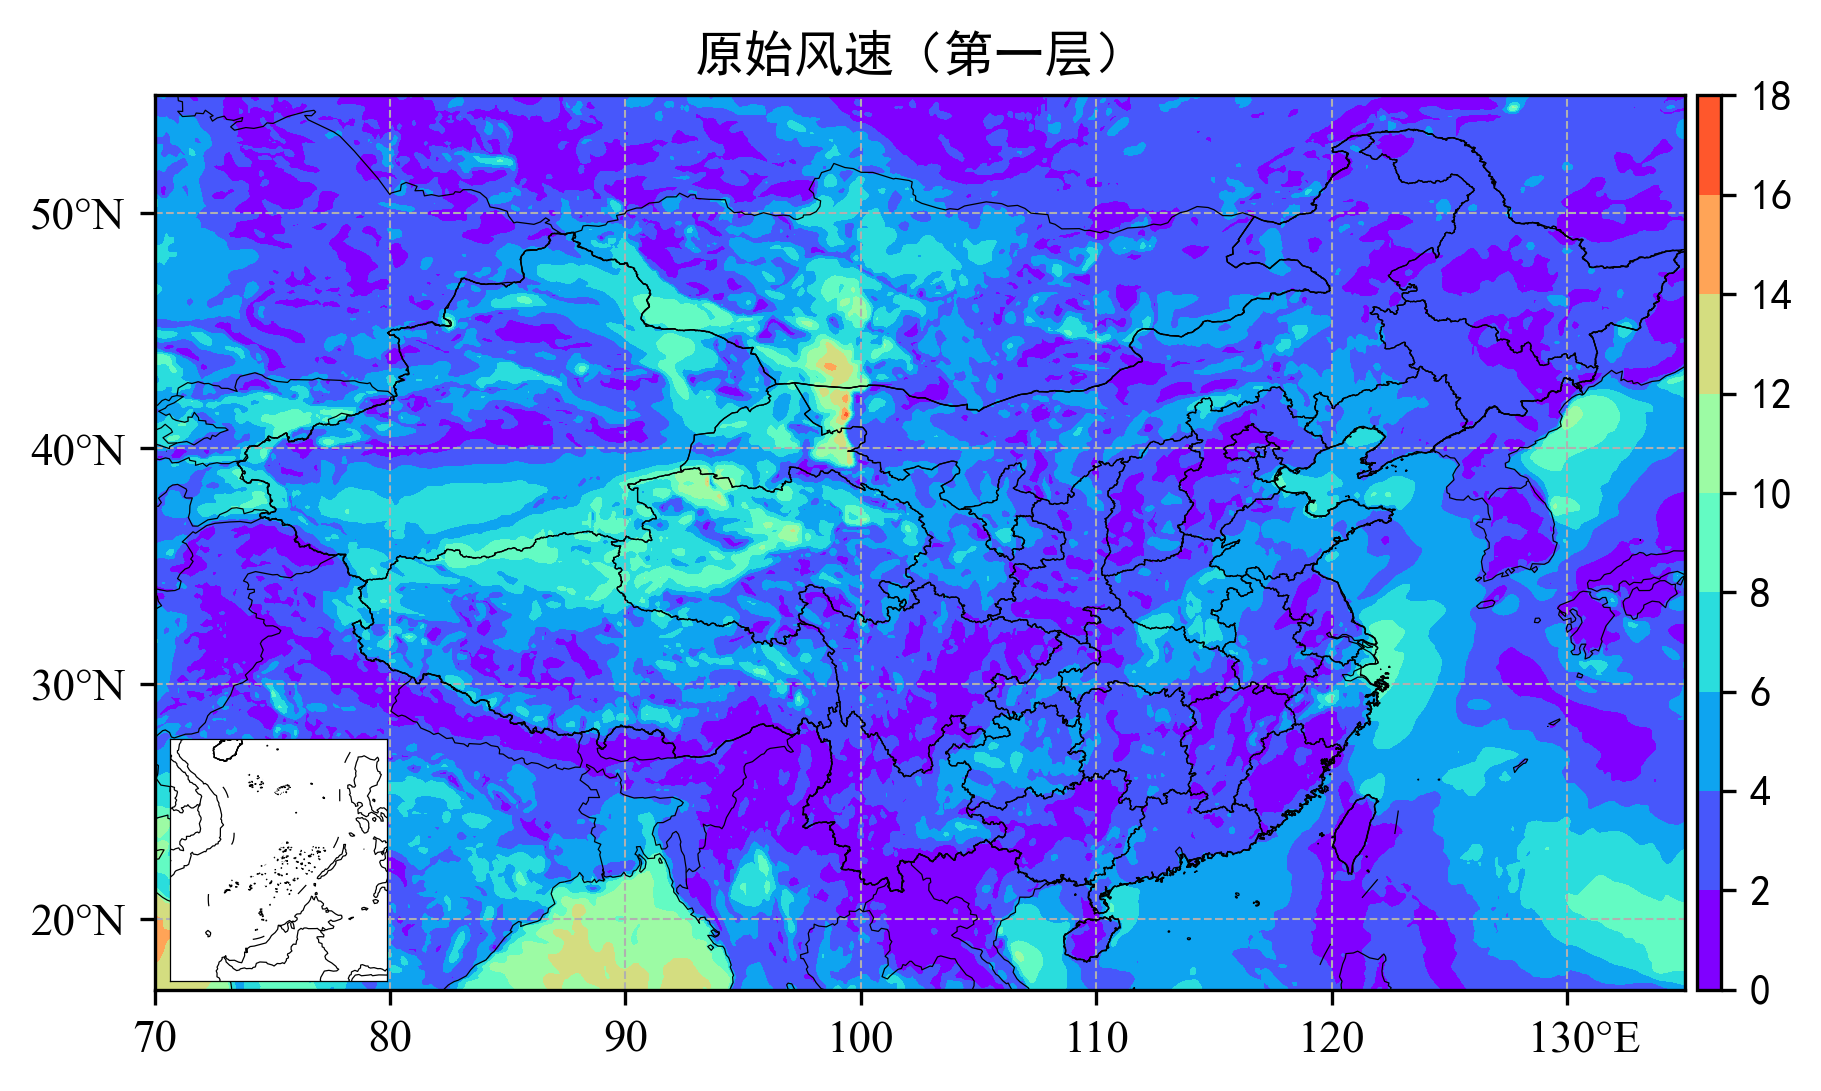

In [15]:
# 使用 meteva_base 绘制地图 - 原始风速
map_extend = [70,135,17,55]
axs,minaxs = meb.creat_axs(1,map_extend,ncol = 1)
# 创建网格数据对象
wind_speed_grd = meb.grid_data(grd0, wind_speed[:, :, 0])
# 绘制等值线图
image = meb.add_contourf(axs[0], wind_speed_grd)
axs[0].set_title('原始风速（第一层）')

返回结果中自动添加了南海小地图，请注意返回结果中包含了两个绘图框列表


Text(0.5, 1.0, '粗糙度订正后风速（第一层）')

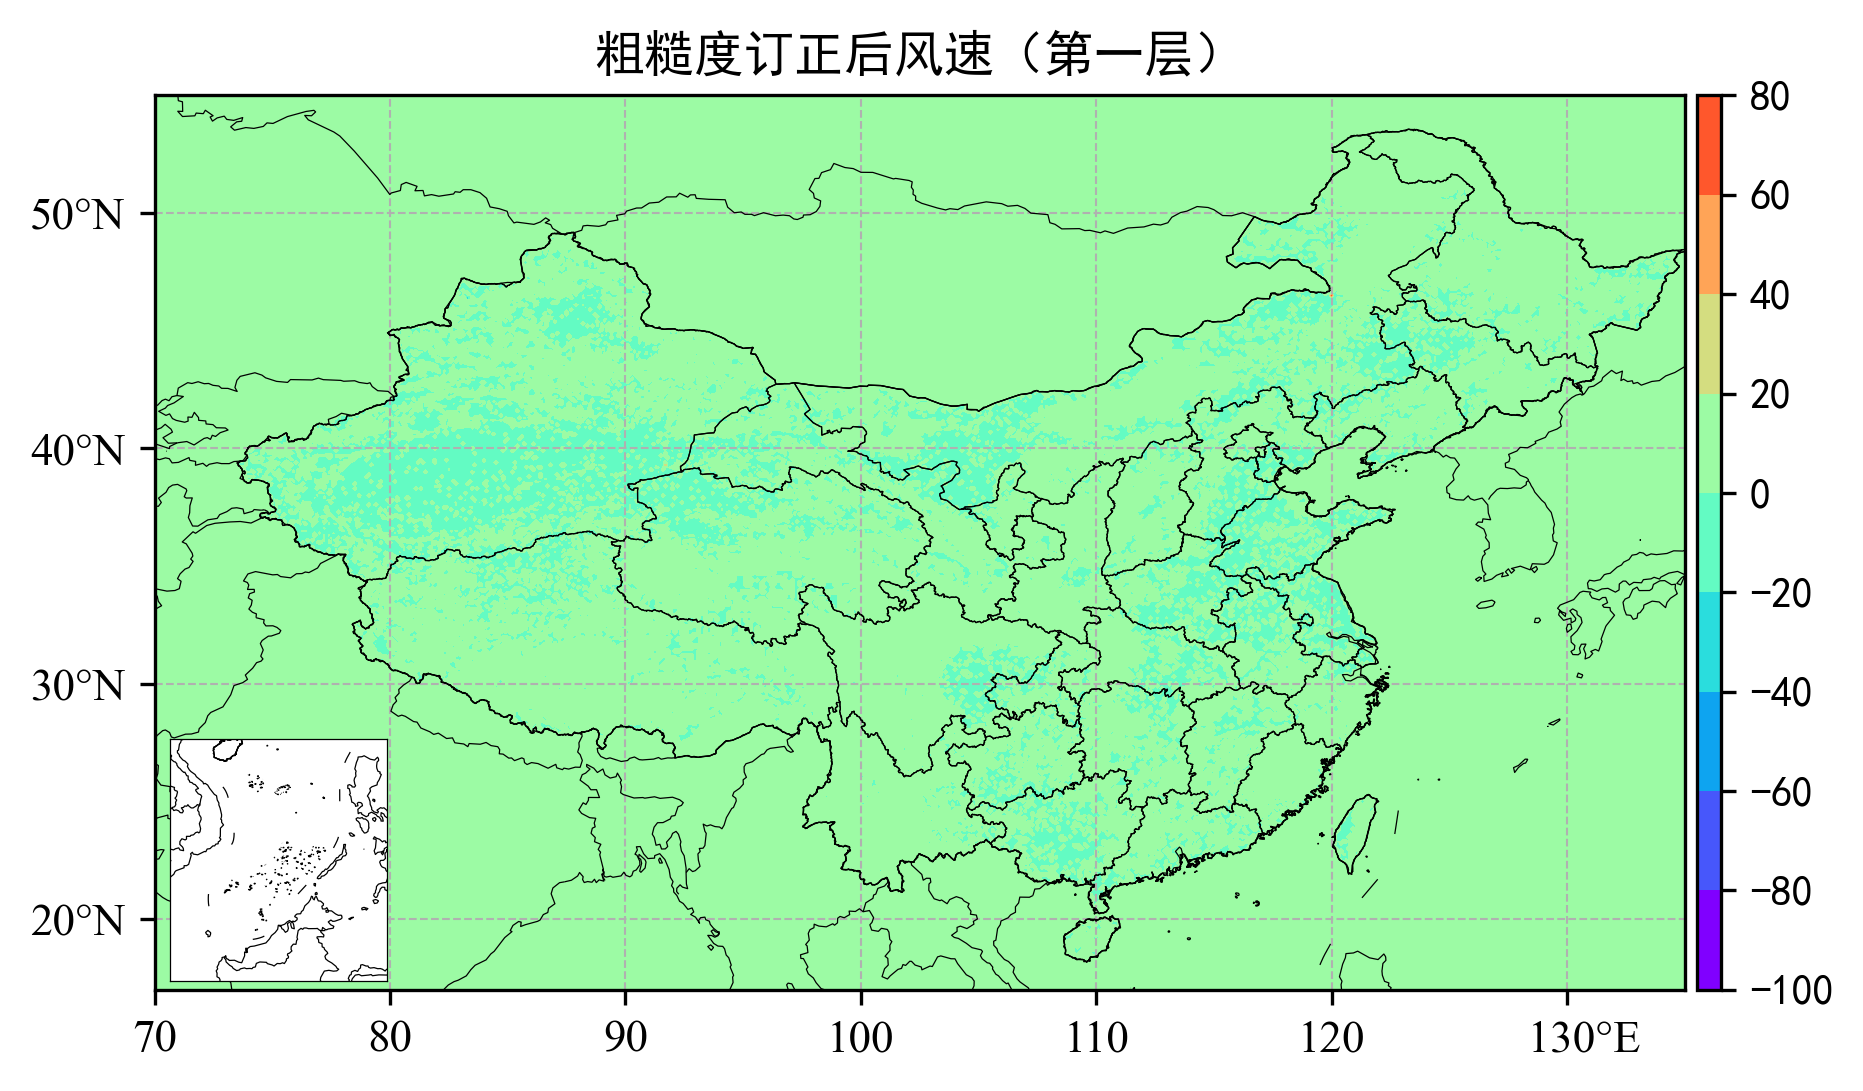

In [16]:
# 使用 meteva_base 绘制地图 - 粗糙度订正后风速
map_extend = [70,135,17,55]
axs,minaxs = meb.creat_axs(1,map_extend,ncol = 1)
# 创建网格数据对象
corrected_wind_grd = meb.grid_data(grd0, corrected_wind[:, :, 0])
# 绘制等值线图
image = meb.add_contourf(axs[0], corrected_wind_grd)
axs[0].set_title('粗糙度订正后风速（第一层）')

返回结果中自动添加了南海小地图，请注意返回结果中包含了两个绘图框列表


Text(0.5, 1.0, '最终风速（第一层）')

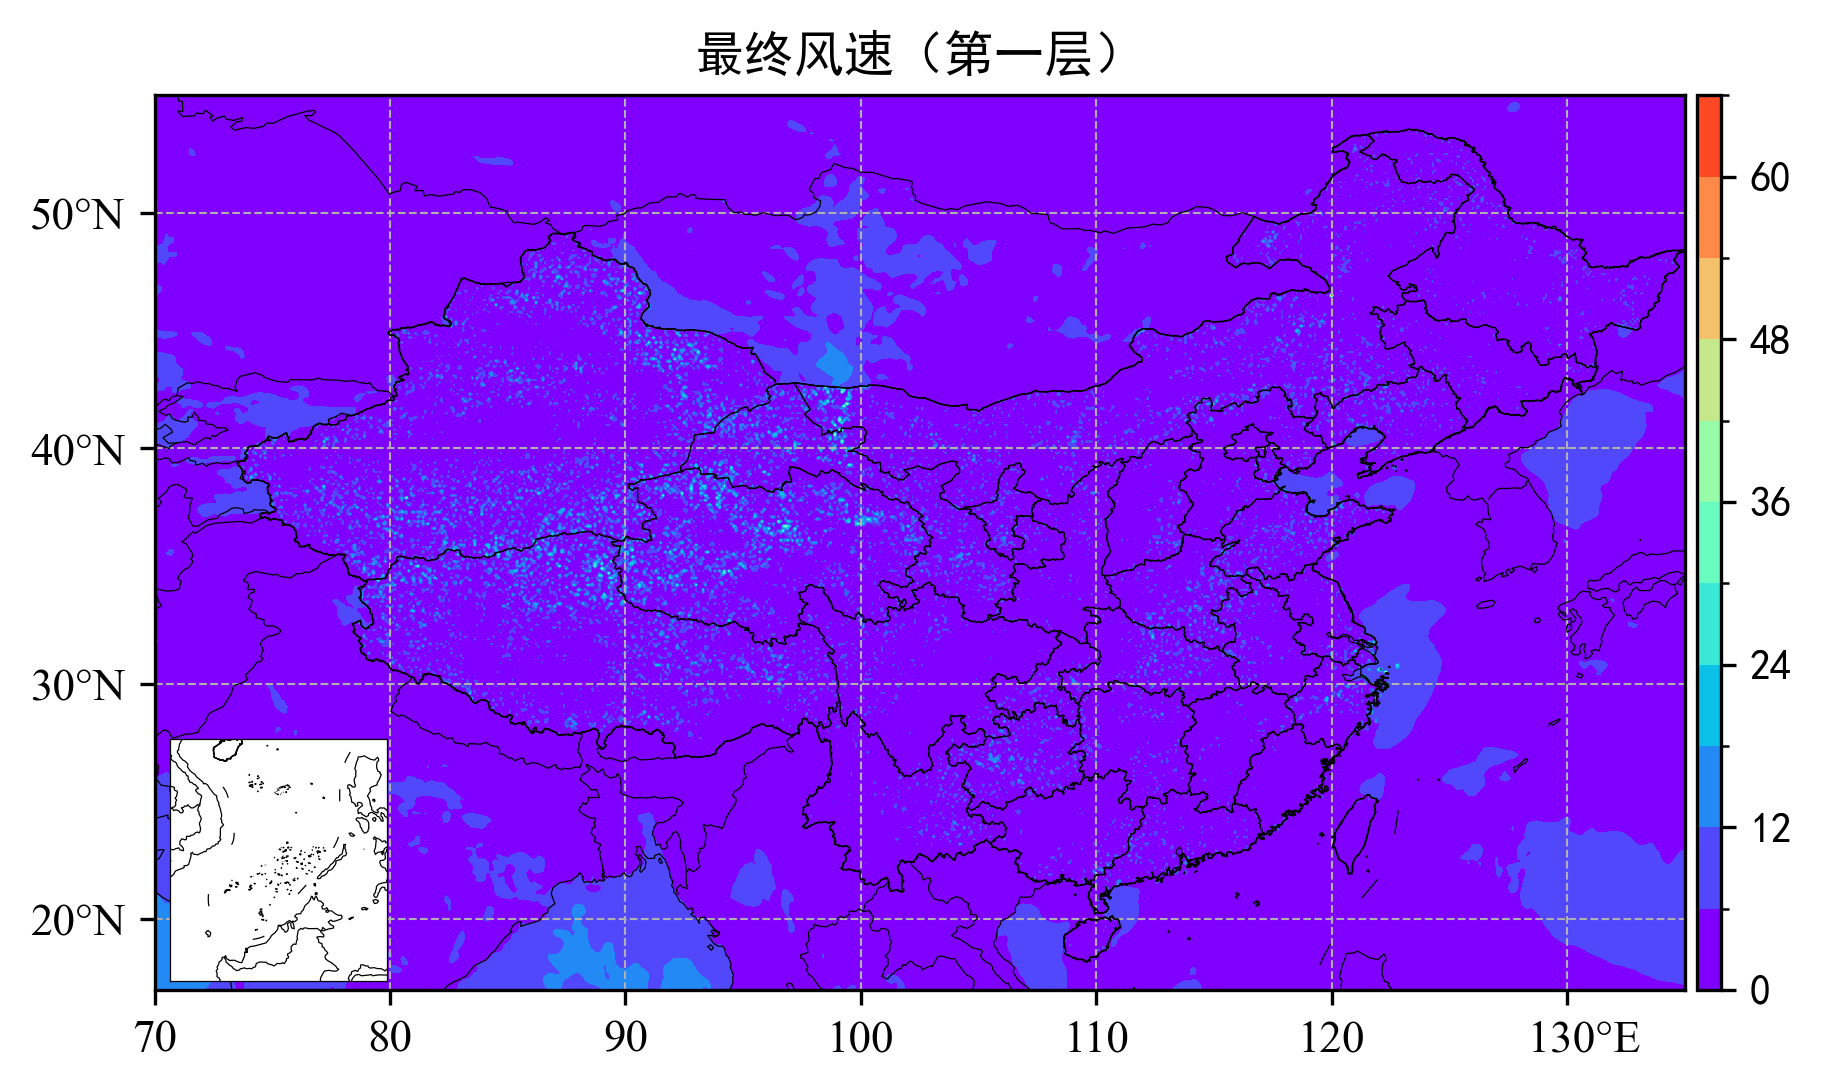

In [17]:
# 使用 meteva_base 绘制地图 - 最终风速
map_extend = [70,135,17,55]
axs,minaxs = meb.creat_axs(1,map_extend,ncol = 1)
# 创建网格数据对象
final_wind_grd = meb.grid_data(grd0, final_wind[:, :, 0])
# 绘制等值线图
image = meb.add_contourf(axs[0], final_wind_grd)
axs[0].set_title('最终风速（第一层）')

返回结果中自动添加了南海小地图，请注意返回结果中包含了两个绘图框列表


Text(0.5, 1.0, '参考高度')

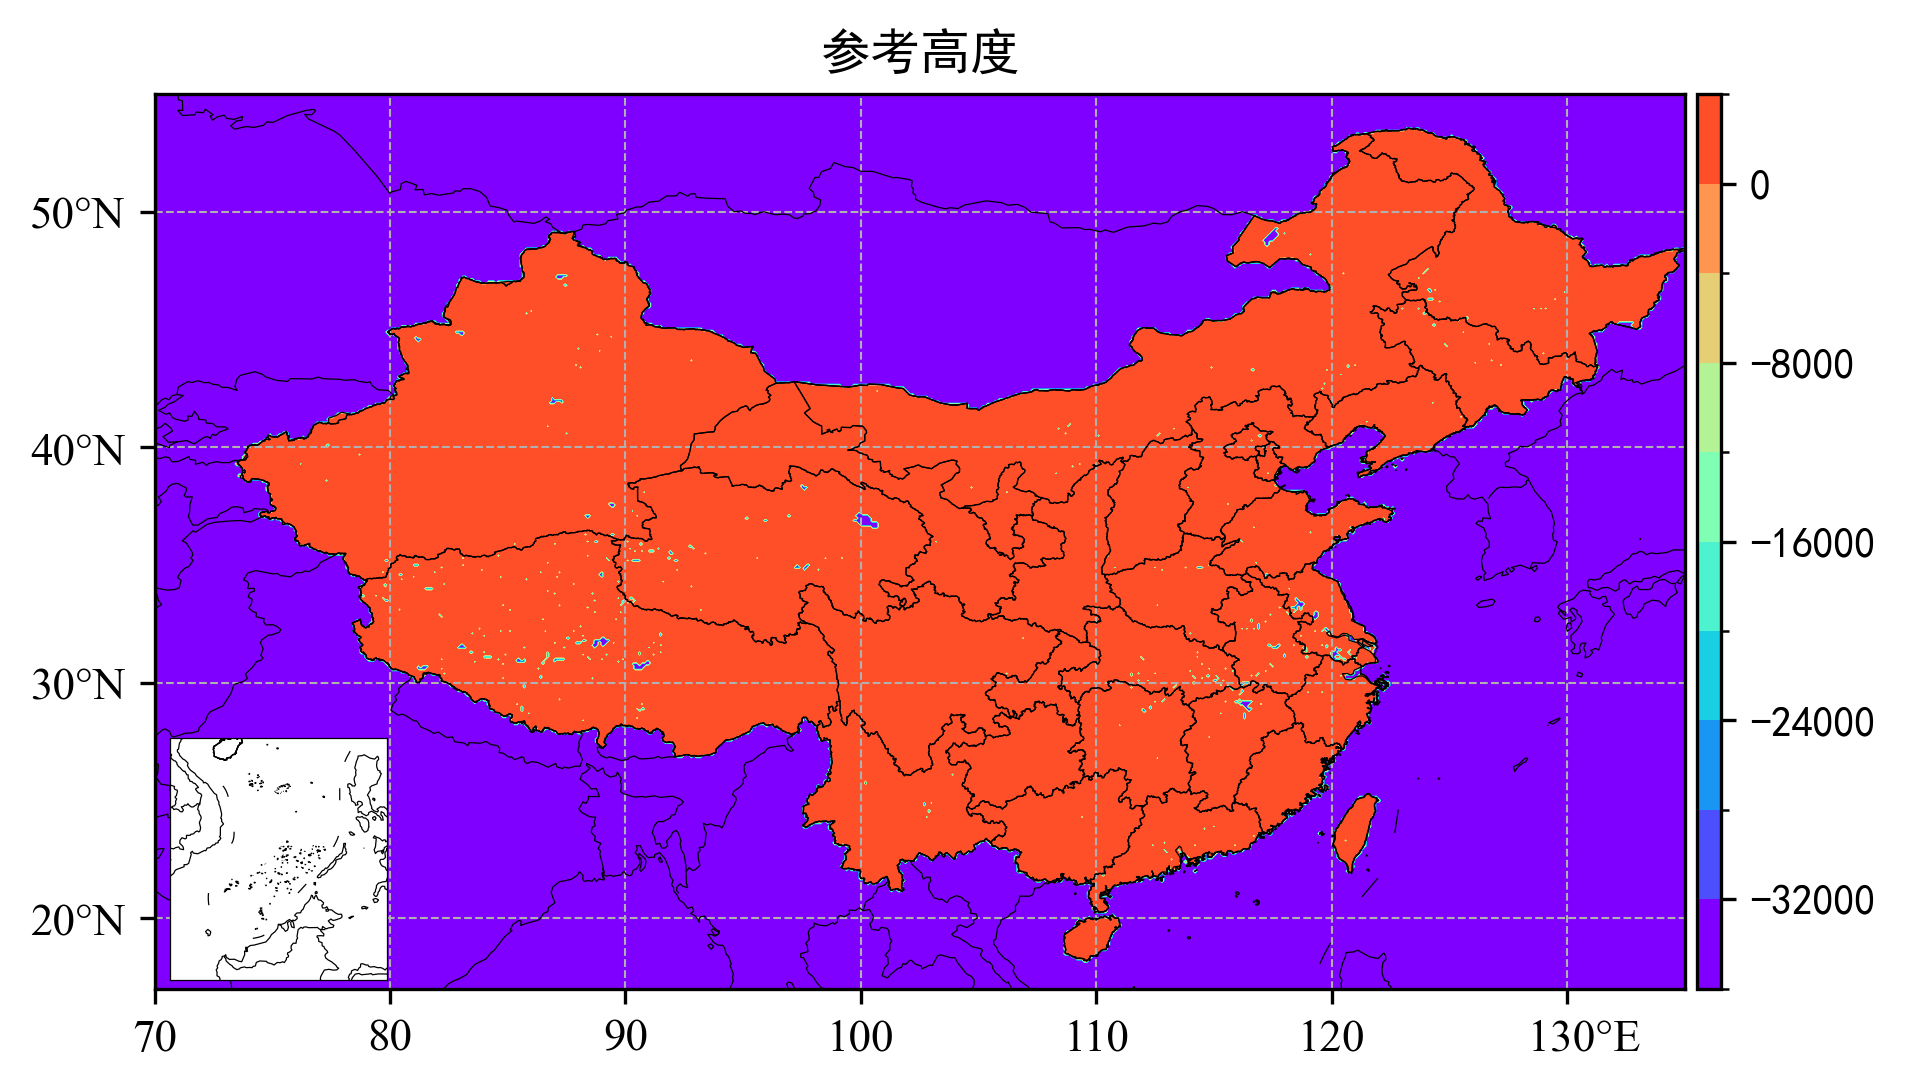

In [18]:
# 使用 meteva_base 绘制地图 - 参考高度
map_extend = [70,135,17,55]
axs,minaxs = meb.creat_axs(1,map_extend,ncol = 1)
# 创建网格数据对象
h_ref_grd = meb.grid_data(grd0, rc_utils.h_ref)
# 绘制等值线图
image = meb.add_contourf(axs[0], h_ref_grd)
axs[0].set_title('参考高度')

# RoughnessCorrection 

对风速进行地形粗糙度订正和高度订正

#### 参数说明：

| 字段名称 | 类型 | 描述 | 单位 | 注意事项 |
|---------|------|------|------|---------|
| `a_over_s` | 二维浮点型数组（float32） | 地形轮廓粗糙度（无量纲） | 无 | 形状必须为 (lat, lon) |
| `sigma` | 二维浮点型数组（float32） | 网格单元内的高度标准差 | 米 | 形状必须为 (lat, lon) |
| `pporo` | 二维浮点型数组（float32） | 后处理网格地形高度 | 米 | 形状必须为 (lat, lon) |
| `modoro` | 二维浮点型数组（float32） | 插值至后处理网格的模式地形高度 | 米 | 形状必须为 (lat, lon) |
| `z0` | 二维浮点型数组（float32），可选 | 植被粗糙度长度 | 米 | 若为 None，则跳过粗糙度订正步骤 |
| `modres` | 浮点型（float） | 模式原始平均分辨率 | 米 | 通常为模式网格的网格单元边长 |
| `ppres` | 浮点型（float） | 后处理网格分辨率 | 米 | 网格单元平均边长 |

#### 方法说明：

| 方法名称 | 描述 | 参数 | 返回值 |
|---------|------|------|--------|
| `__init__` | 初始化 RoughnessCorrection 类 | a_over_s, sigma, pporo, modoro, modres, ppres, z0 | 无 |
| `process` | 对风速进行地形粗糙度订正和高度订正 | wind_speed, height_grid | np.ndarray |

In [22]:
import numpy as np 
import meteva_base as meb 
from src.wind_downscaling import RoughnessCorrection 

# 1. 准备输入数据 
# 模拟辅助数据
# 假设网格尺寸为 (381, 651)，与之前读取的文件保持一致
n_lat, n_lon = 381, 651

# 模拟地形轮廓粗糙度（无量纲）
a_over_s = np.random.rand(n_lat, n_lon).astype(np.float32)
# 模拟网格单元内的高度标准差（米）
sigma = np.random.rand(n_lat, n_lon).astype(np.float32) * 100
# 模拟后处理网格地形高度（米）
pporo = np.random.rand(n_lat, n_lon).astype(np.float32) * 500
# 模拟插值至后处理网格的模式地形高度（米）
modoro = np.random.rand(n_lat, n_lon).astype(np.float32) * 500
# 读取植被粗糙度长度（米）
z0_grd = meb.read_griddata_from_nc(r"D:\Work\nimm_improver\wind_calculations\resource\COVER_10KM_CHINA.nc")
z0 = z0_grd.values.squeeze()

# 设置分辨率参数
modres = 4000.0  # 模式网格分辨率（4km）
ppres = 1000.0   # 后处理网格分辨率（1km）

In [23]:
# 2. 创建 RoughnessCorrection 实例
rc = RoughnessCorrection(
    a_over_s=a_over_s,
    sigma=sigma,
    pporo=pporo,
    modoro=modoro,
    modres=modres,
    ppres=ppres,
    z0=z0  # 如果不需要粗糙度订正，可以设置为 None
)

# 3. 准备风速数据
# 读取风速数据
wind_speed_grd = meb.read_griddata_from_nc(r"D:\Work\nimm_improver\wind_calculations\resource\WIND_SPEED_10KM_CHINA.nc")
wind_speed = wind_speed_grd.values.squeeze()  # 形状：(levels, lat, lon) 或 (batch, levels, lat, lon)

In [25]:
# 准备高度网格
# 一维高度网格
height_levels = np.array([10], dtype=np.float32)  # 单位：米

# 4. 执行风速订正
corrected_wind = rc.process(wind_speed_grd, height_levels)


In [26]:
# 5. 结果处理
# 将结果转换为网格数据对象
grd0 = meb.grid([70, 135, 0.1], [17, 55, 0.1],
                gtime=wind_speed_grd.time.values,
                dtime_list=wind_speed_grd.dtime.values)
corrected_wind_grd = meb.grid_data(grd0, corrected_wind)

返回结果中自动添加了南海小地图，请注意返回结果中包含了两个绘图框列表


Text(0.5, 1.0, '订正后风速')

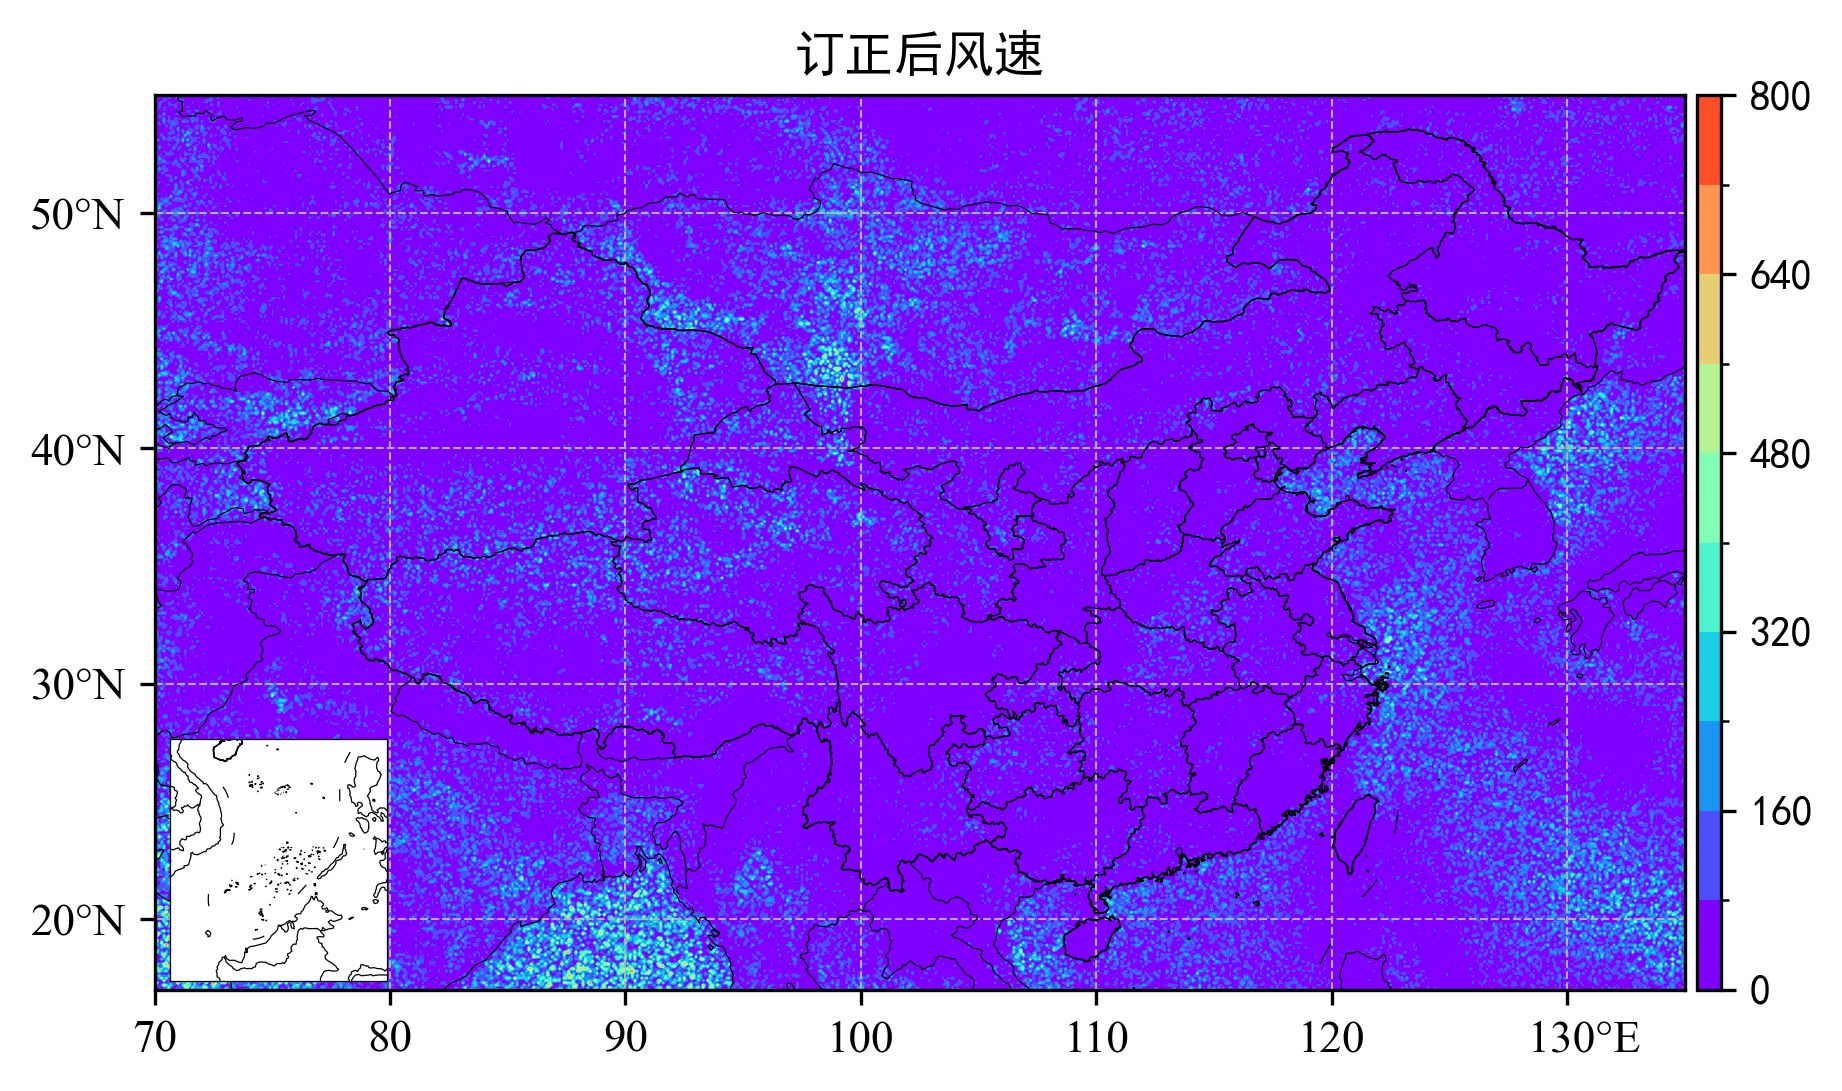

In [27]:
# 6. 可视化结果
map_extend = [70, 135, 17, 55]
axs, minaxs = meb.creat_axs(1, map_extend, ncol=1)
image = meb.add_contourf(axs[0], corrected_wind_grd)
axs[0].set_title('订正后风速')